inputfile: /home/tron/SAR/dataset/S1A_IW_RAW__0SDV_20241005T100129_20241005T100201_055966_06D7F2_D90B.SAFE/s1a-iw-raw-s-vh-20241005t100129-20241005t100201-055966-06d7f2.dat
subswath: 1
number_of_bursts: 6
show_debug_figure: True
raw_data_figure: False
rc_figure: False
ac_figure: True
subswath_index (all): [3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69]
subswath_index (processing): [33]
basename: S1A_IW_RAW_20241005_IW1
Nrg: 23890 , Naz: 1409
num_burst_idx: 0
subswath_index: 33
Burst Start Time (gps_epoch_0): 1412157721.979744
Ephemeris Time Window: [1412157707.0, 1412157739.0]
Ephemeris Shape: (798, 15)
Total packets count: 52051
Packets in swath count: 16908
Datatype of burst_packets: <class 'list'>
burst_packets_size 1409
first_angle -0.011806451612903225
last_angle 0.010997067448680349
num_replicas: 3.6378635060211737
dc_rate: -7612.744245842502
burst_duration: 0.8205557191303194
PRF: 1717.1289738780367
bandwidth: 3123.3404146012476
num_replicas: 3.6378635060211737 , mosaic_azi_len: 

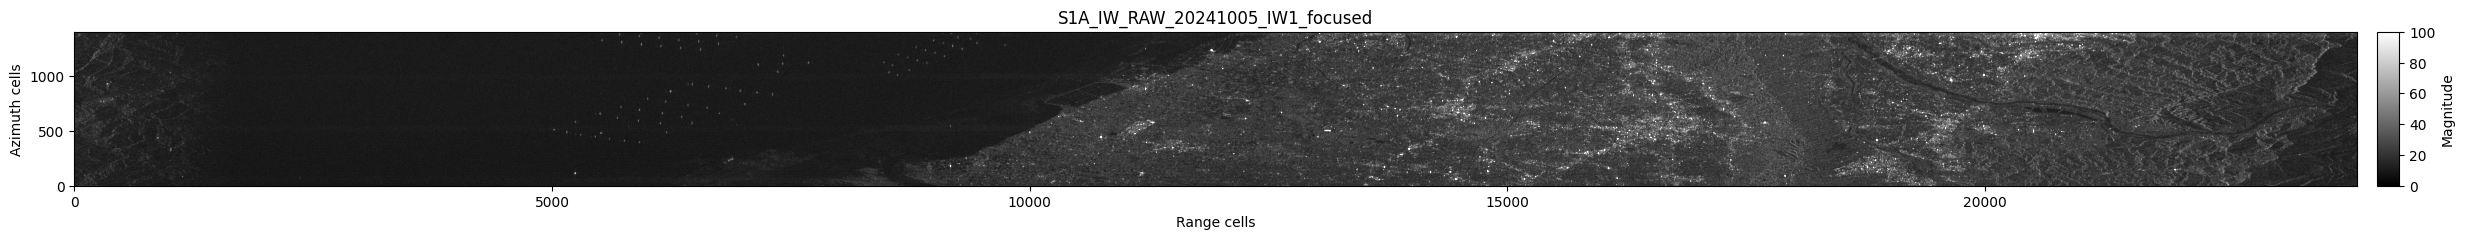

In [6]:
import sentinel1decoder
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.interpolate import interp1d
import tifffile
import time
import os, re
from pathlib import Path

SPEED_OF_LIGHT : float = 3e8
GRAVITATIONAL_CONST: float = 6.67430e-11 # unit: m^3 kg^-1 s^-2
EARTH_MASS_KG: float = 5.972e24 
EARTH_RADIUS_M: float = 6371e3 
DEG_TO_RAD : float = np.pi / 180
US_TO_S : float = 1e-6 
MHZ_TO_HZ : float = 1e6
GHZ_TO_HZ : float = 1e9

def subswath_indices(l0file, subswath: int, completeness_ratio: float = 0.90):
    """
    依 subswath=1/2/3 回傳該子波束的 burst ID 清單。
    同時自動丟掉兩端不完整的 burst（以該 swath 的中位行數作為完整基準）。
    
    Parameters
    ----------
    l0file : object
        需提供
        - l0file.packet_metadata  (pandas.DataFrame, MultiIndex 含 'Azimuth Block Number')
        - l0file.get_burst_metadata(bid) -> pandas.DataFrame（其中有 'Swath Number' 欄）
    subswath : int
        1, 2, 或 3（對應 IW10, IW11, IW12）
    completeness_ratio : float
        行數門檻，相對該 swath 中位數的比例。預設 0.90。
    
    Returns
    -------
    List[int]
    """
    if subswath not in (1, 2, 3):
        raise ValueError("subswath must be 1, 2, or 3")

    # 1) 取得所有 burst IDs（Azimuth Block Number）
    az_blocks = l0file.packet_metadata.index.get_level_values('Azimuth Block Number')
    bursts_ids = np.unique(az_blocks)

    # 2) 建 swath → [burst_ids] 對應
    from collections import defaultdict
    bursts_by_swath = defaultdict(list)
    for bid in bursts_ids:
        bm = l0file.get_burst_metadata(int(bid))
        sw = int(bm['Swath Number'].iloc[0])
        bursts_by_swath[sw].append(int(bid))

    # 3) subswath 映射到 Sentinel-1 的 Swath Number（IW10/11/12）
    subswath_to_swathnum = {1: 10, 2: 11, 3: 12}
    target_sw = subswath_to_swathnum[subswath]

    if target_sw not in bursts_by_swath:
        return []

    # 4) 排序該 swath 的 burst IDs
    ids = sorted(bursts_by_swath[target_sw])

    if not ids:
        return ids

    # 5) 用該 swath 內每個 burst 的行數中位數當作「完整」基準
    row_counts = []
    for bid in ids:
        df = l0file.get_burst_metadata(int(bid))
        row_counts.append(df.shape[0])
    row_counts = np.asarray(row_counts, dtype=int)
    median_rows = int(np.median(row_counts))
    thresh = int(np.floor(median_rows * completeness_ratio))

    # 6) 只在「兩端」刪掉不完整的 burst（最前/最後）
    left = 0
    right = len(ids) - 1
    # 前端
    while left <= right and row_counts[left] < thresh:
        left += 1
    # 末端
    while right >= left and row_counts[right] < thresh:
        right -= 1
        
    return ids[left:right+1]

# idx1 = subswath_indices(l0file, 1)  # 期望如 [7, 13, 19, ..., 67]（丟掉 1）
# idx2 = subswath_indices(l0file, 2)  # 期望如 [3, 9, 15, ..., 69]
# idx3 = subswath_indices(l0file, 3)  # 期望如 [5, 11, 17, ..., 65]（丟掉 71）
# print("subswath 1:", idx1)
# print("subswath 2:", idx2)
# print("subswath 3:", idx3)

from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, List, Tuple, BinaryIO, Optional

# ---------- Utilities ----------

def linspace(start: float, stop: float, n: int) -> List[float]:
    if n <= 0:
        return []
    if n == 1:
        return [float(start)]
    step = (stop - start) / float(n - 1)
    return [start + step * i for i in range(n)]

def read_bytes(file_obj: BinaryIO, n: int) -> bytes:
    b = file_obj.read(n)
    if len(b) != n:
        raise EOFError("Unexpected EOF while reading bytes")
    return b

def read_n_bits(buf: bytes, bit_index: int, bit_len: int) -> int:
    """MSB-first bit reading (matches your C++ read_n_bits)."""
    v = 0
    for i in range(bit_len):
        b = bit_index + i
        byte = buf[b >> 3]
        bit  = (byte >> (7 - (b & 7))) & 1
        v = (v << 1) | bit
    return v

# ---------- CCSDS Primary Header (6 bytes = 48 bits) ----------
PRIMARY_HEADER_FIELDS = [
    "version", "type", "sec_hdr_flag", "apid",
    "sequence_flags", "sequence_count", "packet_data_length"
]
PRIMARY_HEADER_BITS = [3, 1, 1, 11, 2, 14, 16]  # sums to 48 bits

# ---------- Sentinel-1 Secondary Header (62 bytes = 496 bits) ----------
SECONDARY_HEADER_FIELDS = [
    "coarse_time","fine_time","sync_marker","data_take_id","ecc_number","na_1",
    "test_mode","rx_channel_id","instrument_configuration_id",
    "sc_data_word_index","sc_data_word","space_packet_count","pri_count","error_flag",
    "na_2","baq_mode","baq_block_length","na_3","range_decimation","rx_gain",
    "tx_ramp_rate_sign","tx_ramp_rate_mag","pulse_start_frequency_sign",
    "pulse_start_frequency_mag","pulse_length","na_4","rank","pri","swst","swl",
    "ssb_flag","polarisation","temperature_compensation","na_5","elevation_beam_address",
    "na_6","azimuth_beam_address","calibration_mode","na_7","tx_pulse_number",
    "signal_type","na_8","swap","swath_number","num_quadratures","na_9"
]
SECONDARY_HEADER_BITS = [
    32,16,32,32,8,1,3,4,32,8,16,32,32,1,2,5,8,8,8,8,1,15,1,15,24,3,5,24,24,24,
    1,3,2,2,4,2,10,2,1,5,4,3,1,8,16,8
]
SECONDARY_HEADER_SIZE = 62  # bytes

# ---------- Minimal “swath number → string” fallback ----------
SWATH_NUM_TO_STRING = {
    1: "S1", 2: "S2", 3: "S3", 4: "S4", 5: "S5"
}

# ---------- Range decimation map (placeholder; adjust if you rely on it) ----------
RANGE_DECIMATION = {i: i for i in range(256)}  # easy stub; fill with actual table if needed

# ---------- LUT: azimuth beam address → angle (rad) ----------
AZIMUTH_BEAM_ADDRESS_TO_ANGLE: List[float] = linspace(-0.018, +0.018, 1024)

# ---------- L0Packet ----------

@dataclass
class L0Packet:
    primary_header: Dict[str, int]
    secondary_header: Dict[str, int]
    raw_user_data: bytes
    packet_index: int

    _data_format: Optional[str] = None  # 'A'/'B'/'C'/'D'

    @staticmethod
    def _parse_header(bytez: bytes, bit_lengths: List[int], field_names: List[str]) -> Dict[str, int]:
        bit_index = 0
        out: Dict[str, int] = {}
        for name, nbits in zip(field_names, bit_lengths):
            out[name] = read_n_bits(bytez, bit_index, nbits)
            bit_index += nbits
        return out

    @staticmethod
    def open_file(path: str) -> BinaryIO:
        return open(path, "rb")

    @classmethod
    def get_next_packet(cls, file_obj: BinaryIO, packet_index: int) -> Optional["L0Packet"]:
        try:
            primary_bytes = read_bytes(file_obj, 6)
        except EOFError:
            return None
        primary_header = cls._parse_header(primary_bytes, PRIMARY_HEADER_BITS, PRIMARY_HEADER_FIELDS)

        secondary_bytes = read_bytes(file_obj, SECONDARY_HEADER_SIZE)
        secondary_header = cls._parse_header(secondary_bytes, SECONDARY_HEADER_BITS, SECONDARY_HEADER_FIELDS)

        packet_length = primary_header["packet_data_length"]  # CCSDS units
        user_data_length = packet_length + 1 - SECONDARY_HEADER_SIZE
        if user_data_length < 0:
            raise ValueError("Invalid packet length computed (negative user_data_length)")

        user_data = read_bytes(file_obj, user_data_length)
        pkt = cls(primary_header, secondary_header, user_data, packet_index)
        pkt._set_data_format()
        return pkt

    @classmethod
    def get_packets(cls, l0_source: Union[str, BinaryIO], num_packets: int = 0) -> List["L0Packet"]:
        close_after = False
        if isinstance(l0_source, str):
            file_obj = cls.open_file(l0_source)
            close_after = True
        else:
            file_obj = l0_source

        all_packets: List[L0Packet] = []
        index = 0
        try:
            while True:
                if num_packets and index >= num_packets:
                    break
                pkt = cls.get_next_packet(file_obj, index)
                if pkt is None:
                    break
                all_packets.append(pkt)
                index += 1
        finally:
            if close_after:
                file_obj.close()
        return all_packets

    @classmethod
    def get_packets_in_swath(cls, l0_source: Union[str, BinaryIO], swath_name: str) -> List["L0Packet"]:
        all_packets = cls.get_packets(l0_source, num_packets=0)
        print("Total packets count:", len(all_packets))
        
        swath_packets = []
        for p in all_packets:
            if p.get_swath() == swath_name:
                swath_packets.append(p)
                
        if not swath_packets:
            raise RuntimeError(f"No packets found for swath: {swath_name}")
        return swath_packets

    @classmethod
    def get_packets_in_bursts(cls, l0_source: Union[str, BinaryIO], swath_name: str) -> List[List["L0Packet"]]:
        """Groups all packets from a data source into bursts for a specific swath."""
        swath_packets = cls.get_packets_in_swath(l0_source, swath_name)
        print("Packets in swath count:", len(swath_packets))

        return cls.get_packets_in_bursts_from_packets(swath_packets, swath_name)

    @classmethod
    def get_packets_in_bursts_from_packets(cls, swath_packets: List["L0Packet"], swath_name: str,
                                           get_cal_packets: bool = False) -> List[List["L0Packet"]]:
        """Groups a pre-filtered list of swath packets into bursts."""
        bursts: List[List[L0Packet]] = []
        current_burst: List[L0Packet] = []
        prev_az: Optional[int] = None
        prev_pri_count: Optional[int] = None

        for i, pkt in enumerate(swath_packets):
            type_check = (pkt.get_data_format() != 'D') if get_cal_packets else (pkt.get_data_format() == 'D')
            if type_check and (pkt.get_swath() == swath_name):
                az = pkt.secondary_header["azimuth_beam_address"]
                pri_count = pkt.secondary_header["pri_count"]

                if prev_az is None:
                    prev_az = az
                    prev_pri_count = pri_count

                # Burst split condition (port of your C++):
                if az < prev_az or (prev_pri_count is not None and pri_count > prev_pri_count + 1):
                    if len(current_burst) < 1000:
                        current_burst = []
                    else:
                        bursts.append(current_burst)
                        current_burst = []
                current_burst.append(pkt)
                prev_az = az
                prev_pri_count = pri_count

            if i == len(swath_packets) - 1 and current_burst:
                bursts.append(current_burst)

        return bursts

    # ---------- Calculated helpers ----------
    def _set_data_format(self) -> None:
        baq_mode = self.secondary_header["baq_mode"]
        test_mode = self.secondary_header["test_mode"]
        type_c = {3, 4, 5}
        type_d = {12, 13, 14}
        if baq_mode == 0:
            self._data_format = 'A' if (test_mode % 3 == 0) else 'B'
        elif baq_mode in type_c:
            self._data_format = 'C'
        elif baq_mode in type_d:
            self._data_format = 'D'
        else:
            raise ValueError("Invalid BAQ mode")

    def get_data_format(self) -> str:
        if self._data_format is None:
            self._set_data_format()
        return self._data_format

    # ---------- What you need ----------
    def get_azimuth_beam_angle(self) -> float:
        idx = self.secondary_header["azimuth_beam_address"]
        if not (0 <= idx < len(AZIMUTH_BEAM_ADDRESS_TO_ANGLE)):
            raise IndexError("azimuth_beam_address out of range")
        return AZIMUTH_BEAM_ADDRESS_TO_ANGLE[idx]

    def get_swath(self) -> str:
        n = self.secondary_header["swath_number"]
        return SWATH_NUM_TO_STRING.get(n, str(n))

    # ---------- (Stubs) Other getters you might fill later ----------
    def get_signal(self):
        raise NotImplementedError("BAQ C/D decoding not ported yet in this minimal version.")

# ---------- Convenience: first/last/min/max for one burst ----------

def first_last_angles(burst_packets: List[L0Packet]) -> Dict[str, float]:
    if not burst_packets:
        raise ValueError("Input burst_packets list cannot be empty")
    first_angle = burst_packets[0].get_azimuth_beam_angle()
    print("Datatype of burst_packets:", type(burst_packets))
    last_angle  = burst_packets[-1].get_azimuth_beam_angle()
    
    # More efficient way to get min/max angles
    all_angles = [p.get_azimuth_beam_angle() for p in burst_packets]
    amin = min(all_angles)
    amax = max(all_angles)
    
    return {"first_angle": first_angle, "last_angle": last_angle, "min": amin, "max": amax}

# plot debug figures
def fcx_plot_debug_figures(radar_data: np.ndarray, show_debug_figure: bool, title_name: str, xlabel: str, ylabel: str, clim_max: float = 0.2):
    if not hasattr(fcx_plot_debug_figures, "counter"):
        fcx_plot_debug_figures.counter = 1
    if show_debug_figure:
        radar_data = np.divide(np.abs(radar_data), np.max(np.max(np.abs(radar_data))))
        plt.figure(figsize=(30, 6))
        im = plt.imshow(np.abs(radar_data), cmap='gray', aspect='auto')
        plt.title(title_name)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.gca().tick_params(axis='both', which='major')
        plt.gca().invert_yaxis()
        plt.clim(0, clim_max)
        filename = f"{fcx_plot_debug_figures.counter:03d}_{title_name}.png"
        plt.colorbar(im)
        plt.savefig(filename, bbox_inches='tight')
        plt.close()
        fcx_plot_debug_figures.counter += 1

# preprocesesing

def fcx_preprocessing(l0file, selection, Naz, Nrg):
    RGDEC = selection["Range Decimation"].unique()[0]
    PRI = selection["PRI"].unique()[0]
    rank = selection["Rank"].unique()[0]
    suppressed_data_time = 320/(8*sentinel1decoder.constants.F_REF)
    range_start_time = selection["SWST"].unique()[0] + suppressed_data_time
    wavelength = sentinel1decoder.constants.TX_WAVELENGTH_M
    Fr_hz = sentinel1decoder.utilities.range_dec_to_sample_rate(RGDEC)
    range_sample_period = 1 / Fr_hz
    PRF = 1 / PRI

    sample_num_along_range_line = np.arange(0, Nrg, 1)
    fast_time_vec = range_start_time + (range_sample_period * sample_num_along_range_line)
    slant_range_vec = ((rank * PRI) + fast_time_vec) * SPEED_OF_LIGHT/2
    ecef_vels = l0file.ephemeris.apply(lambda x: math.sqrt(x["X-axis velocity ECEF"]**2 + x["Y-axis velocity ECEF"]**2 +x["Z-axis velocity ECEF"]**2), axis=1)
    velocity_interp = interp1d(l0file.ephemeris["POD Solution Data Timestamp"].unique(), ecef_vels.unique(), fill_value="extrapolate")
    space_velocities = selection.apply(lambda x: velocity_interp(x["Coarse Time"] + x["Fine Time"]), axis=1).to_numpy().astype(float)
    WGS84_A = sentinel1decoder.constants.WGS84_SEMI_MAJOR_AXIS_M
    WGS84_B = sentinel1decoder.constants.WGS84_SEMI_MINOR_AXIS_M
    vp_approx = space_velocities[Naz // 2] 
    gps_epoch = (selection["Coarse Time"] + 1.0 * selection["Fine Time"]).to_numpy(dtype=float)
    gps_epoch_0 = gps_epoch[0]
    gps_epoch_1 = gps_epoch[1]
    time_delta = gps_epoch_1 - gps_epoch_0

    print(f"Burst Start Time (gps_epoch_0): {gps_epoch_0}")
    eph_times = l0file.ephemeris['POD Solution Data Timestamp']
    print(f"Ephemeris Time Window: [{eph_times.min()}, {eph_times.max()}]")
    print(f"Ephemeris Shape: {l0file.ephemeris.shape}")

    return Fr_hz, vp_approx, PRI, PRF, rank, wavelength, range_start_time, time_delta, Fr_hz, WGS84_A, WGS84_B, slant_range_vec, gps_epoch_0

# RC

def fcx_range_compression(radar_data: np.ndarray, selection, Nrg, Fr_hz, show_debug_figure) -> np.ndarray:
    radar_data = np.fft.fft(radar_data, axis=1)
    TXPSF = selection["Tx Pulse Start Frequency"].unique()[0]
    TXPRR = selection["Tx Ramp Rate"].unique()[0]
    TXPL = selection["Tx Pulse Length"].unique()[0]
    num_tx_vals = int(TXPL*Fr_hz)
    tx_replica_time_vals = np.linspace(-TXPL/2, TXPL/2, num=num_tx_vals)
    phi1 = TXPSF + TXPRR*TXPL/2
    phi2 = TXPRR/2
    tx_replica = np.exp(2j * np.pi * (0*phi1*tx_replica_time_vals + phi2*tx_replica_time_vals**2))
    range_filter = np.zeros(Nrg, dtype=complex)
    index_start = np.ceil((Nrg-num_tx_vals)/2)-1
    index_end = num_tx_vals+np.ceil((Nrg-num_tx_vals)/2)-2
    range_filter[int(index_start):int(index_end+1)] = tx_replica
    range_filter = np.conjugate(np.fft.fft(range_filter))
    radar_data = np.multiply(radar_data, range_filter)
    radar_data = np.fft.ifftshift(np.fft.ifft(radar_data, axis=1), axes=1)
    fcx_plot_debug_figures(radar_data, show_debug_figure, title_name="range compression", xlabel="tau", ylabel="eta", clim_max=0.1)
    return radar_data, TXPL

# Doppler centroid estimation

# edit Naz -> burst_packets_size
def get_doppler_centroid_rate(vp_approx: float,
                              first_angle: float,
                              last_angle: float,
                              PRI: float,
                              burst_packets_size: int,
                              wavelength: float) -> float:
    """
    由天線掃描角速度估計 Doppler Centroid Rate。
    antenna_steering_rate = (last - first) / (PRI * burst_packets_size)
    dc_rate = -2 * v * antenna_steering_rate / wavelength
    """
    antenna_steering_rate = (last_angle - first_angle) / (PRI * burst_packets_size)
    # print("burst_packets_size", burst_packets_size)
    dc_rate = -2.0 * vp_approx * antenna_steering_rate / wavelength
    return float(dc_rate)


def get_deramping_signal(dc_rate: float,
                         eta_vec: np.ndarray,
                         burst_duration: float) -> np.ndarray:
    """
    產生 TOPS de-ramping 訊號: exp(j*pi*dc_rate*(t - T/2)^2)
    """
    return np.exp(1j * np.pi * dc_rate * (eta_vec - 0.5 * burst_duration) ** 2)


def dce_preconditioning(radar_data: np.ndarray,
                        deramping_signal: np.ndarray) -> np.ndarray:
    """
    將每列乘上 deramping_signal (broadcast)
    radar_data: (Naz, Nrg), deramping_signal: (Naz,)
    """
    return radar_data * deramping_signal[:, None]


def get_wrapped_estimates(precoditioned_burst: np.ndarray,
                          PRF: float) -> np.ndarray:
    """
    相鄰方位相位差累加，取角度得到 wrapped Fdc (每個 range 一個估計)
    """
    products = precoditioned_burst[:-1, :] * np.conjugate(precoditioned_burst[1:, :])
    phase_difference_sum = products.sum(axis=0)  # (Nrg,)
    wrapped_estimates = -PRF * np.angle(phase_difference_sum) / (2.0 * np.pi)
    return wrapped_estimates.astype(np.float64)


def compute_fine_dc_estimates(wrapped_estimates: np.ndarray,
                              num_rng_blocks: int) -> np.ndarray:
    """
    將 wrapped_estimates 依 range 方向分成 num_rng_blocks 區塊，逐塊平均。
    與原 C++ 行為一致：最後 end_index 以 (num_rng - 1) 當上界的半開區間。
    """
    num_rng = int(wrapped_estimates.size)
    rng_block_size = num_rng // num_rng_blocks
    fine_dc_estimates = np.empty(num_rng_blocks, dtype=np.float64)

    for blk in range(num_rng_blocks):
        start = blk * rng_block_size
        end   = (start + rng_block_size) if (start + rng_block_size) < num_rng else (num_rng - 1)
        # 半開區間，不含 end
        if end <= start:
            # 萬一切到空區塊，就取最後一點或 0
            fine_dc_estimates[blk] = wrapped_estimates[-1] if num_rng > 0 else 0.0
            continue
        seg = wrapped_estimates[start:end]
        fine_dc_estimates[blk] = float(seg.sum()) / float(end - start)

    return fine_dc_estimates

def get_unwrapped_estimates(fine_dc_estimates: np.ndarray,
                            tau_vec_short_offset: np.ndarray,
                            PRF: float,
                            dense_grid_scalar: int = 8) -> np.ndarray:
    """
    由粗估的 fine_dc_estimates 展相位：
      1) 構造長度 M*d 的 F, 前 M 點為 floor(|exp(j*2π*dc/PRF)|)=1
      2) FFT 求最大能量頻率 → 得 a, 與相位 → 得 b
      3) 計算殘差相位 res, 回推 unwrapped_estimates
    """
    num_est = fine_dc_estimates.size
    dt = float(tau_vec_short_offset[1] - tau_vec_short_offset[0])
    N = int(num_est * dense_grid_scalar)

    F = np.zeros(N)
    F[:num_est] = np.floor(np.abs(np.exp(2j * np.pi * fine_dc_estimates / PRF)))

    F = np.fft.fft(F, axis=0)
    power = np.abs(F) ** 2
    max_index = int(np.argmax(power))
    freqs = np.fft.fftfreq(N, d=dt)

    v = float(freqs[max_index])
    a = v / dt
    b = np.angle(F[max_index]) / (2.0 * np.pi)

    res_phase_1 = np.exp(2j * np.pi * fine_dc_estimates / PRF)
    res_phase_2 = np.exp(-1j * (a * tau_vec_short_offset + b))
    res = np.angle(res_phase_1 * res_phase_2) / (2.0 * np.pi)

    return (a * tau_vec_short_offset + b + res) * PRF


def polyfit_cubic_moments(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    以矩法組出 4x4 法方程解三次多項式係數，[d, c, b, a]（低→高）
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    Sx = np.zeros(7, dtype=float)
    Sy = np.zeros(4, dtype=float)
    for xi, yi in zip(x, y):
        p = 1.0
        for j in range(7):
            if j <= 3:
                Sy[j] += p * yi
            Sx[j] += p
            p *= xi

    A = np.array([
        [Sx[0], Sx[1], Sx[2], Sx[3]],
        [Sx[1], Sx[2], Sx[3], Sx[4]],
        [Sx[2], Sx[3], Sx[4], Sx[5]],
        [Sx[3], Sx[4], Sx[5], Sx[6]],
    ], dtype=float)
    b = Sy.copy()

    try:
        coeffs = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        coeffs, *_ = np.linalg.lstsq(A, b, rcond=None)
    return coeffs.astype(np.float64)  # [d, c, b, a]


def polyval_cubic(coeffs: np.ndarray, t: np.ndarray) -> np.ndarray:
    """
    f(t) = d + c*t + b*t^2 + a*t^3, 其中 coeffs = [d, c, b, a]
    """
    d, c, b, a = map(float, coeffs)
    t = np.asarray(t, dtype=float)
    return (((a * t) + b) * t + c) * t + d


def get_doppler_centroid(unwrapped_estimates: np.ndarray,
                         tau_vec_short_offset: np.ndarray,
                         delay: float,
                         TXPL: float,
                         Nrg: int,
                         initial_time: float) -> np.ndarray:
    """
    用 (tau_vec_short_offset, unwrapped_estimates) 擬合三次多項式，
    再在完整 range 時間軸 (長度 Nrg) 上評估得到 full-length doppler centroid。
    """
    poly = polyfit_cubic_moments(tau_vec_short_offset, unwrapped_estimates)

    tau_vec = np.linspace(delay, delay + TXPL, Nrg)
    tau_vec_offset = tau_vec - initial_time

    doppler_centroid_full = polyval_cubic(poly, tau_vec_offset)
    # print("Unwrapped F_DC:", doppler_centroid_full[0], ",", doppler_centroid_full[-1])
    # print("size of unwrapped fdc:", doppler_centroid_full.shape)
    return doppler_centroid_full

def get_dc_and_dcrate(radar_data: np.ndarray, Nrg, Naz, PRI, PRF, rank, range_start_time, wavelength, vp_approx, TXPL, subswath, bursts_data, num_burst_idx) -> np.ndarray :
    # dc estimation
    burst_duration    = Naz * PRI
    doppler_bandwidth = PRF * 0.4
    delay             = rank * PRI + range_start_time
    eta_vec           = np.linspace(0.0, burst_duration, Naz)
    num_rng_blocks    = 15 # 要分成幾塊平均
    dense_grid_scalar = 8

    # calculate first/last azimuth angle
    bursts = L0Packet.get_packets_in_bursts(inputfile, str(subswath + 9)) # "10", "11", "12" means IW1, IW2, IW3
    angles = first_last_angles(bursts[num_burst_idx])
    burst_packets_size = len(bursts[num_burst_idx])
    first_angle = angles["first_angle"]
    last_angle = angles["last_angle"]
    # print("number of bursts:", len(bursts))
    # print("len of first burst", len(bursts[0]))
    # print("len of second burst", len(bursts[1]))
    # print("len of third burst", len(bursts[2]))
    print("burst_packets_size", burst_packets_size)
    print("first_angle", first_angle)
    print("last_angle", last_angle)
    
    # 2) DC rate
    dc_rate = get_doppler_centroid_rate(vp_approx, first_angle, last_angle, PRI, burst_packets_size, wavelength)

    # 3) De-ramp & preconditioning
    deramping_signal   = get_deramping_signal(dc_rate, eta_vec, burst_duration)
    precoditioned_burst = dce_preconditioning(radar_data, deramping_signal)

    # 4) Wrapped Fdc
    wrapped_estimates = get_wrapped_estimates(precoditioned_burst, PRF)

    # 5) 分塊平均 → fine_dc_estimates
    tau_vec_short  = np.linspace(delay, delay + TXPL, num_rng_blocks)  # 每塊的「代表時間」（原 C++）
    initial_time   = float(tau_vec_short[0])

    fine_dc_estimates = compute_fine_dc_estimates(wrapped_estimates, num_rng_blocks)

    # 6) 展相位（由粗到細）
    tau_vec_short_offset = tau_vec_short - initial_time

    unwrapped_estimates = get_unwrapped_estimates(
        fine_dc_estimates, tau_vec_short_offset, PRF, dense_grid_scalar
    )

    # 7) 擬合三次多項式並評估整長度 Doppler Centroid
    doppler_centroid = get_doppler_centroid(
        unwrapped_estimates=unwrapped_estimates,
        tau_vec_short_offset=tau_vec_short_offset,
        delay=delay,
        TXPL=TXPL,
        Nrg=Nrg,
        initial_time=initial_time
    )

    # # for simplicuty, return doppler_centroid = 0 is acceptable for imaging
    # doppler_centroid = 0.0 * np.ones(Nrg, dtype=np.float64)

    # print("burst_duration", burst_duration)

    return doppler_centroid, dc_rate, burst_duration, doppler_bandwidth

# Azimuth freq UFR

def mosaic_rows(radar_data: np.ndarray, num_replicas: float) -> np.ndarray:
    """
    將 2D 矩陣 (Nrg, Naz) 沿著 axis=1 (方位方向) 做 mosaic
      - 重複 floor(Nrg) 次整段
      - 再補 fractional 的前綴
    """
    radar_data = np.asarray(radar_data)
    Nrg, Naz = radar_data.shape
    replica_int = int(np.floor(num_replicas))
    replica_tail = int(np.floor((num_replicas - replica_int) * Naz))
    parts = []
    if replica_int > 0:
        parts.append(np.concatenate([radar_data] * replica_int, axis=1))
    if replica_tail > 0:
        parts.append(radar_data[:, :replica_tail])
    return np.concatenate(parts, axis=1)

def azimuth_frequency_ufr(radar_data: np.ndarray, dc_rate, burst_duration, PRF, Naz, doppler_bandwidth, show_debug_figure) -> np.ndarray:
    """
    azimuth_frequency_ufr (頻域 UFR)
      1) (Naz, Nrg) → 轉置 → (Nrg, Naz)
      2) 沿 azimuth 軸(=1) 做 FFT + fftshift
      3) 依 replicas 數在 azimuth 頻域拼接
      4) De-ramping: exp(-j*pi*(1/dc_rate)*f_az^2)
      5) 頻域裁切(中央帶寬 doppler_bandwidth)
      6) IFFT 回時域
      7) Re-ramping: exp(+j*pi*(1/dc_rate)*f_az^2)
      8) 最後轉置回 (Naz_out, Nrg)
    """

    radar_data = radar_data.T # (Nrg, Naz) (tau, eta) -> (Naz, Nrg) (eta, tau)
    radar_data = np.fft.fft(radar_data, axis=1)  # (feta, tau)
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="range doppler after rc", xlabel="tau", ylabel="feta", clim_max=0.1)
    radar_data = np.fft.fftshift(radar_data, axes=1)  # (tau, feta)
    num_replicas = abs(dc_rate * burst_duration / PRF)
    bandwidth = num_replicas * PRF / 2.0
    # mosaic
    mosaic_azi_len = int(np.floor(num_replicas * Naz))
    radar_data = mosaic_rows(radar_data, num_replicas) # (Nrg, mosaic_azi_len)
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="range doppler after mosaic", xlabel="tau", ylabel="feta", clim_max=0.1)
    # deramp
    eps = 1e-30
    az_freqs = np.linspace(-bandwidth, bandwidth, radar_data.shape[1], endpoint=False)
    deramp = np.exp(-1j * np.pi * (1.0 / (dc_rate)) * (az_freqs ** 2))
    radar_data *= deramp[None, :]
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="range doppler after deramp", xlabel="tau", ylabel="feta", clim_max=0.1)
    # low-pass filtering using fft
    radar_data = np.fft.fft(radar_data, axis=1)
    tmp = np.zeros_like(radar_data)
    bw = int(np.floor(doppler_bandwidth))
    start = max(int(mosaic_azi_len // 2 - bw // 2), 0)
    end = min(int(mosaic_azi_len // 2 + bw // 2), mosaic_azi_len)
    width = max(0, end - start)
    tmp[:, :width] = radar_data[:, start:start + width]
    radar_data = np.fft.ifft(tmp, axis=1)  # (tau, feta)
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="range doppler after LPF", xlabel="tau", ylabel="feta", clim_max=0.1)
    print("num_replicas:", num_replicas)
    print("dc_rate:", dc_rate)
    print("burst_duration:", burst_duration)
    print("PRF:", PRF)
    print("bandwidth:", bandwidth)
    print("num_replicas:", num_replicas, ", mosaic_azi_len:", mosaic_azi_len, ", bandwidth:", bandwidth, ", bw:", bw, ", start:", start, ", end:", end, ", width:", width)
    # reramp
    reramp = np.exp( 1j * np.pi * (1.0 / (dc_rate)) * (az_freqs ** 2))
    radar_data *= reramp[None, :]
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="range doppler after reramp", xlabel="tau", ylabel="feta", clim_max=0.1)
    return radar_data.T # (Naz_out, Nrg)

# Azimuth compression

from scipy.interpolate import interp1d

def azimuth_compression(radar_data: np.ndarray, l0file, wavelength, Naz, time_delta, Fr_hz, dc_rate, burst_duration, PRF, WGS84_A,
                        WGS84_B, slant_range_vec, gps_epoch_0, show_debug_figure) -> np.ndarray:
    Naz_ufr, Nrg = radar_data.shape
    CENTER_FREQ = SPEED_OF_LIGHT / float(wavelength)
    oversample_factor = float(Naz_ufr) / float(Naz)
    time_delta_os = time_delta / oversample_factor

    col_t  = "POD Solution Data Timestamp"
    col_px = "X-axis position ECEF"
    col_py = "Y-axis position ECEF"
    col_pz = "Z-axis position ECEF"
    col_vx = "X-axis velocity ECEF"
    col_vy = "Y-axis velocity ECEF"
    col_vz = "Z-axis velocity ECEF"

    eph = (l0file.ephemeris
           .sort_values(col_t)
           .drop_duplicates(subset=col_t, keep="last"))

    t_eph = eph[col_t].to_numpy(dtype=float)
    px = eph[col_px].to_numpy(dtype=float)
    py = eph[col_py].to_numpy(dtype=float)
    pz = eph[col_pz].to_numpy(dtype=float)
    vx = eph[col_vx].to_numpy(dtype=float)
    vy = eph[col_vy].to_numpy(dtype=float)
    vz = eph[col_vz].to_numpy(dtype=float)

    ########## new edit start ##########
    def safe_interp1d(x, y, target_len):
        # 僅允許內插，不允許外插
        f = interp1d(x, y, kind="linear", bounds_error=False, fill_value=np.nan)
        x_new = np.linspace(x[0], x[-1], target_len)
        y_new = f(x_new)
        # 若有 nan（代表外插），則補齊為最接近的邊界值
        nan_mask = np.isnan(y_new)
        if np.any(nan_mask):
            y_new[:np.argmax(~nan_mask)] = y[0]
            y_new[np.argmax(~nan_mask[::-1]):] = y[-1]
        return interp1d(x_new, y_new, kind="linear", bounds_error=True)
        
    f_px = safe_interp1d(t_eph, px, Naz_ufr)
    f_py = safe_interp1d(t_eph, py, Naz_ufr)
    f_pz = safe_interp1d(t_eph, pz, Naz_ufr)
    f_vx = safe_interp1d(t_eph, vx, Naz_ufr)
    f_vy = safe_interp1d(t_eph, vy, Naz_ufr)
    f_vz = safe_interp1d(t_eph, vz, Naz_ufr)

    t_vec = gps_epoch_0 + time_delta_os * np.arange(Naz_ufr, dtype=float)
    # print("t_vec", t_vec)
    # 修正 t_vec 超出插值範圍的問題
    t_vec = np.clip(t_vec, t_eph[0], t_eph[-1])
    x = f_px(t_vec);  y = f_py(t_vec);  z = f_pz(t_vec)
    vx_ = f_vx(t_vec); vy_ = f_vy(t_vec); vz_ = f_vz(t_vec)
    ########## new edit end ##########

    # print("t_eph", t_eph)
    # print("px:", px)
    # print("py:", py)
    # print("pz:", pz)
    # print("vx:", vx)
    # print("vy:", vy)
    # print("vz:", vz)
    # print("x:", x)
    # print("y:", y)
    # print("z:", z)
    # print("vx_:", vx_)
    # print("vy_:", vy_)
    # print("vz_:", vz_)
    # print("shape of t_eph:", t_eph.shape)
    # print("shape of px:", px.shape)
    # print("shape of py:", py.shape)
    # print("shape of pz:", pz.shape)
    # print("shape of vx:", vx.shape)
    # print("shape of vy:", vy.shape)
    # print("shape of vz:", vz.shape)
    # print("shape of f_px:", f_px.x.shape)
    # print("shape of f_py:", f_py.x.shape)
    # print("shape of f_pz:", f_pz.x.shape)
    # print("shape of f_vx:", f_vx.x.shape)
    # print("shape of f_vy:", f_vy.x.shape)
    # print("shape of f_vz:", f_vz.x.shape)

    velocities_norm = np.sqrt(vx_**2 + vy_**2 + vz_**2)  # (Naz_ufr,)
    range_freqs = np.linspace(-Fr_hz/2.0, Fr_hz/2.0, Nrg, endpoint=True) # ftau
    num_replicas = abs(dc_rate * burst_duration / PRF)
    az_freqs = np.linspace(-num_replicas*PRF/2.0, num_replicas*PRF/2.0, Naz_ufr, endpoint=True) # f_eta
    radar_data = np.fft.fftshift(np.fft.fft(radar_data, axis=1), axes=1) # (feta, ftau)

    eps = 1e-30
    lat = z / (x + eps)
    earth_rad_num   = (WGS84_A*WGS84_A*np.cos(lat))**2 + (WGS84_B*WGS84_B*np.sin(lat))**2
    earth_rad_denom = (WGS84_A*np.cos(lat))**2        + (WGS84_B*np.sin(lat))**2
    earth_radius = np.sqrt(earth_rad_num / (earth_rad_denom + eps))      # (Naz_ufr,)
    sat_alt = np.sqrt(x*x + y*y + z*z)                                   # (Naz_ufr,)

    earth_radius      = earth_radius[:, None]                 # (Naz_ufr,1)
    sat_alt           = sat_alt[:, None]                      # (Naz_ufr,1)
    velocities_norm   = velocities_norm[:, None]              # (Naz_ufr,1)
    slant_range_vec   = slant_range_vec[None, :]              # (1,Nrg)
    Ftau              = range_freqs[None, :]                  # (1,Nrg)
    Feta              = az_freqs[:, None]                     # (Naz_ufr,1)

    numerator   = earth_radius**2 + sat_alt**2 - slant_range_vec**2 # (Naz_ufr,Nrg)
    denominator = 2.0 * earth_radius * sat_alt # (Naz_ufr,1)
    beta = numerator / (denominator + eps) # (Naz_ufr,Nrg)
    v_ground = (earth_radius * velocities_norm * beta) / (sat_alt + eps) # (Naz_ufr,Nrg)
    # print("velocities_norm", velocities_norm)
    v_eff_mat = np.sqrt(velocities_norm * v_ground + eps) # (Naz_ufr,Nrg)

    D_mig_mat = np.sqrt(1.0 - (wavelength**2 * (Feta**2)) / (4.0 * v_eff_mat**2 + eps)) # (Naz_ufr,Nrg)
    src_fm_rate = (2.0 * v_eff_mat**2 * (CENTER_FREQ**3) * D_mig_mat**2) \
                / (SPEED_OF_LIGHT * slant_range_vec * (Feta**2 + eps)) # (Naz_ufr,Nrg)

    Hsrc = np.exp(-1j * np.pi * (Ftau**2) / src_fm_rate) # (Naz_ufr,Nrg)
    radar_data *= Hsrc
    radar_data = np.fft.ifft(radar_data, axis=1) # (feta, tau)
    Hac = np.exp(4j * np.pi * slant_range_vec * D_mig_mat * CENTER_FREQ / SPEED_OF_LIGHT) # (Naz_ufr,Nrg)
    radar_data *= Hac
    # 輸出 az_fm_rate（供後續 UFR time-domain 使用）
    az_fm_rate = -(2.0 * (v_eff_mat**2) * (D_mig_mat**3)) / (wavelength * slant_range_vec) # (Naz_ufr,Nrg)
    radar_data = np.fft.ifft(radar_data, axis=0) # (eta, tau)
    fcx_plot_debug_figures(radar_data, show_debug_figure, title_name="azimuth compression", xlabel="tau", ylabel="eta", clim_max=0.1)

#     print("t_vec[0]:", t_vec[0])
#     print("velocities_norm[0]:", velocities_norm[0])
#     print("range_freqs[0]:", range_freqs[0])
#     print("num_replicas:", num_replicas)
#     print("az_freqs[0]:", az_freqs[0])
#     print("lat[0]:", lat[0])
#     print("Ftau[0]:", Ftau[0])
#     print("Feta[0]:", Feta[0])
    # print("v_eff_mat[0]:", v_eff_mat[0])
    # print("D_mig_mat[0]:", D_mig_mat[0])
#     print("")

    return radar_data, az_fm_rate

# Azimuth time UFR

def linear_resample_rows(radar_data: np.ndarray, new_len: int) -> np.ndarray:
    """
    將 2D 陣列 radar_data (Nrg, Naz) 沿 axis=1 以線性插值重採樣到 new_len
    """
    radar_data = np.asarray(radar_data)
    Nrg, Naz = radar_data.shape
    if new_len == Naz:
        return radar_data.copy()

    old_idx = np.linspace(0.0, Naz - 1.0, Naz)
    new_idx = np.linspace(0.0, Naz - 1.0, new_len)
    i0 = np.floor(new_idx).astype(int)
    i1 = np.minimum(i0 + 1, Naz - 1)
    w = (new_idx - i0)[None, :]  # (1, new_len)

    return radar_data[:, i0] * (1.0 - w) + radar_data[:, i1] * w

def tile_rows(radar_data: np.ndarray, num_tiles: int) -> np.ndarray:
    return np.concatenate([radar_data] * num_tiles, axis=1)

def azimuth_time_ufr(radar_data: np.ndarray, az_fm_rate, dc_rate, doppler_centroid, doppler_bandwidth, PRF,
                     burst_duration, subswath, show_debug_figure) -> np.ndarray:
    
    radar_data = radar_data.T # [Naz_ufr, Nrg] -> [Nrg, Naz_ufr]
    az_fm_rate = az_fm_rate.T # [Naz_ufr, Nrg] -> [Nrg, Naz_ufr]
    Nrg, Naz_ufr = radar_data.shape
    num_replicas = abs(dc_rate * burst_duration / PRF)
    bandwidth = (num_replicas * PRF) - doppler_bandwidth
    ka_mean = abs(np.sum(az_fm_rate[0])) / Naz_ufr
    focused_time = burst_duration + (bandwidth - 2.0 * doppler_bandwidth) / ka_mean
    num_pos_tiles = int(np.ceil((focused_time / 2.0) / burst_duration))
    num_neg_tiles = int(np.floor((-focused_time / 2.0) / burst_duration))
    num_tiles = num_pos_tiles - num_neg_tiles 
    # print("ka_mean", ka_mean)
    # print("doppler_bandwidth", doppler_bandwidth)
    # print("bandwidth", bandwidth)
    # print("burst_duration", burst_duration)
    # print("focused_time", focused_time)
    # print("num_pos_tiles", num_pos_tiles)
    # print("num_neg_tiles", num_neg_tiles)
    # print("num_tiles (azimuth_time_ufr):", num_tiles)
    # print("num_replicas (azimuth_time_ufr):", num_replicas)
    # print("dc_rate", dc_rate)
    # print("burst_duration", burst_duration)
    # print("ceil of num_replicas:", np.ceil(num_replicas))

    # new azimuth frequency
    Naz_tfr = num_tiles * Naz_ufr
    eta_vec = np.linspace(-focused_time / 2.0, focused_time / 2.0, Naz_tfr, endpoint=False) # [1, Naz_tfr]

    # mosaicking
    radar_data = tile_rows(radar_data, num_tiles) # [Nrg, Naz_tfr]
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="2d time domain after mosaick", xlabel="tau", ylabel="eta", clim_max=0.1)
    ka_mat = linear_resample_rows(az_fm_rate, Naz_tfr) # [Nrg, Naz_tfr]


    # deramping
    f_dc_vec = doppler_centroid.reshape(Nrg, 1) # [Nrg, 1]
    denom_mat = (dc_rate - ka_mat) # [Nrg, Naz_tfr]
    kt_mat = - ka_mat * dc_rate / denom_mat # [Nrg, Naz_tfr]
    dc_time_mat = - f_dc_vec / denom_mat # [Nrg, Naz_tfr]
    del denom_mat
    eta_add_dc_mat = dc_time_mat + eta_vec # [Nrg, Naz_tfr]    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="before low pass filtering", xlabel="tau", ylabel="eta", clim_max=0.1)     
    deramp_mat = np.exp(-1j * np.pi * kt_mat * (eta_add_dc_mat ** 2.0) + 2j * np.pi * (kt_mat + ka_mat) * dc_time_mat * eta_add_dc_mat) # [Nrg, Naz_tfr]
    radar_data *= deramp_mat
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="2d time domain after deramping", xlabel="tau", ylabel="eta", clim_max=0.1) 

    # low pass filtering
    mid   = Naz_tfr // 2
    start = int(mid - bandwidth / 2.0)
    end   = int(mid + bandwidth / 2.0)
    width = end - start
    radar_data = np.fft.fft(radar_data, axis=1) # [Nrg, Naz_tfr]
    tmp = np.zeros_like(radar_data) # [Nrg, Naz_tfr]
    tmp[:, :width] = radar_data[:, start:start + width]
    radar_data = np.fft.ifft(tmp, axis=1) # [Nrg, Naz_tfr]
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="2d time domain after LPF", xlabel="tau", ylabel="eta", clim_max=0.1) 
    
    # downsample
    if subswath == 1:
        output_extension = int(np.floor(doppler_bandwidth * 0.26)) # 1.15 for IW2, 0.26 for IW1 and IW3
    elif subswath == 2:
        output_extension = int(np.floor(doppler_bandwidth * 1.15 )) # 1.15 for IW2, 0.26 for IW1 and IW3
    elif subswath == 3:
        output_extension = int(np.floor(doppler_bandwidth * 0.26)) # 1.15 for IW2, 0.26 for IW1 and IW3
    else:
        raise ValueError("subswath should be 1, 2, or 3")
        
    output_shape     = int(np.floor(PRF * burst_duration))
    downsample_shape = output_shape + output_extension
    radar_data = linear_resample_rows(radar_data, downsample_shape) # [Nrg, Naz] 
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="2d time domain after down sample", xlabel="tau", ylabel="eta", clim_max=0.1) 
    ka_down_sample_mat = linear_resample_rows(az_fm_rate, downsample_shape) # [Nrg, Naz] 
    print("output_extension:", output_extension)
    print("output_shape:", output_shape)
    print("downsample_shape:", downsample_shape)
    # IW1
    # output_extension: 178
    # output_shape: 1409
    # downsample_shape: 1587
    # eta_downsample_vec shape (1587,)
    
    # Re-ramping
    eta_downsample_vec = eta_vec[:downsample_shape] # [1, Naz]
    eta_downsample_vec = eta_downsample_vec.T # [Naz, 1]
    eta_downsample_mat = (-f_dc_vec / ka_down_sample_mat) + eta_downsample_vec # [Nrg, Naz] 
    print("eta_downsample_vec shape", eta_downsample_vec.shape)

    denom_mat = (dc_rate - ka_down_sample_mat) # [Nrg, Naz] 
    kt_downsample_mat = -ka_down_sample_mat * dc_rate / denom_mat # [Nrg, Naz] 
    del denom_mat
    reramp = np.exp( 1j * np.pi * kt_downsample_mat * (eta_downsample_mat ** 2.0) - 2j * np.pi * (kt_downsample_mat + ka_down_sample_mat) * (-f_dc_vec / ka_down_sample_mat) * eta_downsample_mat) # [Nrg, Naz] 
    radar_data *= reramp # [Nrg, Naz] 
    fcx_plot_debug_figures(radar_data.T, show_debug_figure, title_name="2d time domain after reramp", xlabel="tau", ylabel="eta", clim_max=0.1) 
    print("radar_data[0] shape", radar_data[0].shape)

    radar_data = radar_data.T  # [Naz, Nrg]
    mid2   = downsample_shape // 2
    start2 = int(mid2 - (output_shape // 2))
    end2   = int(start2 + output_shape)
    fcx_plot_debug_figures(radar_data, show_debug_figure, title_name="2d time domain after azimuth time UFR", xlabel="tau", ylabel="eta", clim_max=0.1)
    return radar_data[start2:end2, :]

# plot result

from mpl_toolkits.axes_grid1 import make_axes_locatable
# save png and tif files
def fcx_plot_results_and_save(radar_data_all: np.ndarray, basename: str, status: str):
    # save tif and plot
    tifffile.imwrite((f"../image_results/{basename}_{status}.tif"), np.abs(np.flipud(radar_data_all)).astype(np.uint16))
    figure_y_size = np.ceil(radar_data_all.shape[0] / 750)
    plt.figure(figsize=(30, figure_y_size))
    plt.title(f"{basename}_{status}")
    im = plt.imshow(abs(radar_data_all), cmap='gray', aspect='auto', origin='lower')
    plt.xlabel("Range cells")
    plt.ylabel("Azimuth cells")
    # Use an axes divider to fix the colorbar width
    if status == "focused": plt.clim(0, 100)
    ax = plt.gca()
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="1%", pad=0.2)  # size in percentage, fixed width
    cb = plt.colorbar(im, cax=cax, label="Magnitude")
    plt.savefig((f"../image_results/{basename}_{status}.png"), dpi=180, bbox_inches='tight')
    del radar_data_all

def fcx_save_azimuth_compressed_data(l0file, inputfile, subswath_index, subswath, basename, number_of_bursts, show_debug_figure):
    radar_data_all = []
    ref_azi_len = l0file.get_burst_data(subswath_index[0]).shape[1]

    for num_burst_idx in range (len(subswath_index)):
        # Image sizes
        radar_data = l0file.get_burst_data(subswath_index[num_burst_idx])
        radar_data = radar_data[:, :ref_azi_len]
        radar_data = radar_data.astype(np.complex64)
        Nrg = radar_data.shape[1]
        Naz = radar_data.shape[0]
        print("Nrg:", Nrg, ", Naz:", Naz)
        selection = l0file.get_burst_metadata(subswath_index[num_burst_idx])
        print("num_burst_idx:", num_burst_idx)
        print("subswath_index:", subswath_index[num_burst_idx])
        fcx_plot_debug_figures(radar_data, show_debug_figure, title_name="raw data", xlabel="tau", ylabel="eta", clim_max=1)

        # NEW: preprocess
        Fr_hz, vp_approx, PRI, PRF, rank, wavelength, range_start_time, time_delta, Fr_hz, WGS84_A, WGS84_B, slant_range_vec, gps_epoch_0 = fcx_preprocessing(l0file, selection, Naz, Nrg)

        # range compression
        radar_data, TXPL = fcx_range_compression(radar_data, selection, Nrg, Fr_hz, show_debug_figure)

        # NEW: doppler centroid, doppler centroid rate estimation
        doppler_centroid, dc_rate, burst_duration, doppler_bandwidth = get_dc_and_dcrate(radar_data, Nrg, Naz, PRI, PRF, rank, range_start_time, wavelength, vp_approx, TXPL, subswath, inputfile, num_burst_idx)

        # NEW: azimuth frequency unfolding and resampling
        radar_data = azimuth_frequency_ufr(radar_data, dc_rate, burst_duration, PRF, Naz, doppler_bandwidth, show_debug_figure) # check the ufr function is write or not
        
        # NEW: azimuth compression
        radar_data, az_fm_rate = azimuth_compression(radar_data, l0file, wavelength, Naz, time_delta, Fr_hz, dc_rate, burst_duration, PRF, WGS84_A, WGS84_B, slant_range_vec, gps_epoch_0, show_debug_figure)

        # NEW: azimuth time unfolding and resampling
        radar_data = azimuth_time_ufr(radar_data, az_fm_rate, dc_rate, doppler_centroid, doppler_bandwidth, PRF, burst_duration, subswath, show_debug_figure)
        
        # paste all bursts together
        radar_data_all.append(radar_data)

    radar_data_all = np.vstack(radar_data_all)

    fcx_plot_results_and_save(radar_data_all, basename, status="focused")

def fcx_iwmode_processing(inputfile, subswath, number_of_bursts, show_debug_figure, raw_data_figure, rc_figure, ac_figure):

    l0file = sentinel1decoder.Level0File(inputfile)
    subswath_index = subswath_indices(l0file, subswath) 
    print("subswath_index (all):", subswath_index)
    # 支援多種 burst 選擇方式
    # number_of_bursts: int, list, tuple, 或 (start, end)
    if isinstance(number_of_bursts, int):
        if number_of_bursts < 1:
            pass  # 全部 burst
        else:
            # 只取第 number_of_bursts 個 burst（1-based）
            subswath_index = [subswath_index[number_of_bursts - 1]]
    elif isinstance(number_of_bursts, (list, tuple)):
        if len(number_of_bursts) == 2:
            # 指定 start, end（1-based, inclusive）
            start, end = number_of_bursts
            subswath_index = subswath_index[start - 1:end]
        else:
            # 指定多個 burst index（1-based）
            subswath_index = [subswath_index[i - 1] for i in number_of_bursts]
    print("subswath_index (processing):", subswath_index)

    basename = os.path.basename(inputfile)
    basename = re.match(r"(s1a-iw-raw).*?-(\d{8})", basename, re.IGNORECASE)
    basename = basename.group(1).upper().replace("-", "_") + "_" + basename.group(2) + "_IW" + str(subswath)
    print("basename:", basename)

    for bid in subswath_index:
        l0file.save_burst_data(bid)

    # initialize radar data
    # if raw_data_figure:
    #     fcx_save_raw_data(subswath_index=subswath_index, l0file=l0file, basename=basename)
    # if rc_figure:
    #     fcx_save_range_compressed_data(l0file=l0file, subswath_index=subswath_index, basename=basename, show_debug_figure=show_debug_figure)
    if ac_figure:
        fcx_save_azimuth_compressed_data(subswath=subswath, l0file=l0file, inputfile=inputfile, subswath_index=subswath_index, basename=basename, show_debug_figure=show_debug_figure, number_of_bursts=number_of_bursts)

if __name__ == "__main__":

    for number_of_inputfile in [1]:
        inputs = ["/home/tron/SAR/dataset/S1A_IW_RAW__0SDV_20240806T135224_20240806T135256_055093_06B68A_AE41.SAFE/s1a-iw-raw-s-vv-20240806t135224-20240806t135256-055093-06b68a.dat",
                  "/home/tron/SAR/dataset/S1A_IW_RAW__0SDV_20241005T100129_20241005T100201_055966_06D7F2_D90B.SAFE/s1a-iw-raw-s-vh-20241005t100129-20241005t100201-055966-06d7f2.dat",
                  "/home/tron/SAR/dataset/S1A_IW_RAW__0SDV_20250826T104144_20250826T104216_060706_078DEE_16C1.SAFE/s1a-iw-raw-s-vv-20250826t104144-20250826t104216-060706-078dee.dat"]
        inputfile = inputs[number_of_inputfile]
        for subswath in [1]: 
            # NOTE THAT: SET "number_of_bursts = 0" to process all bursts, get burst indices for the selected subswath
            # number_of_bursts: int, list, tuple, or (start, end)
            number_of_bursts = 6
            # show debug figure or not
            show_debug_figure : bool = True
            # show and save raw data or not
            raw_data_figure : bool = False
            # show and save range compressed data or not
            rc_figure : bool = False
            # show and save azimuth compressed data or not
            ac_figure : bool = True

            print("inputfile:", inputfile)
            print("subswath:", subswath) 
            print("number_of_bursts:", number_of_bursts)
            print("show_debug_figure:", show_debug_figure)
            print("raw_data_figure:", raw_data_figure)
            print("rc_figure:", rc_figure)
            print("ac_figure:", ac_figure)

            fcx_iwmode_processing(inputfile=inputfile, subswath=subswath, number_of_bursts=number_of_bursts, show_debug_figure=show_debug_figure, raw_data_figure=raw_data_figure, rc_figure=rc_figure, ac_figure=ac_figure)